## Setup and Load

In [1]:
import sys
from pathlib import Path
import plotly.express as px
import plotly.graph_objects as go

# Add src to path so we can import our custom loader
sys.path.append(str(Path.cwd().parent))
from src.data_loader import EnergyDataLoader

# Initialize loader (Adjust 'target_building_id' based on your specific CSV column)
print("Loading and cleaning data...")
loader = EnergyDataLoader('../data/electricity_cleaned.csv')
print("Data loaded successfully. Sample data:")
df = loader.load_and_clean(target_building_id='Fox_education_Ollie')
print(df.head())

Loading and cleaning data...
Data loaded successfully. Sample data:
Loading data from ../data/electricity_cleaned.csv...
Loaded 17544 hourly records for building: Fox_education_Ollie
                     energy_kwh
datetime                       
2016-01-01 00:00:00       77.61
2016-01-01 01:00:00       75.83
2016-01-01 02:00:00       80.57
2016-01-01 03:00:00       81.53
2016-01-01 04:00:00       83.55


## The Macro View
Commercial buildings are subject to peak-demand pricing. By visualizing the macro trends, we can identify baseline loads versus peak loads

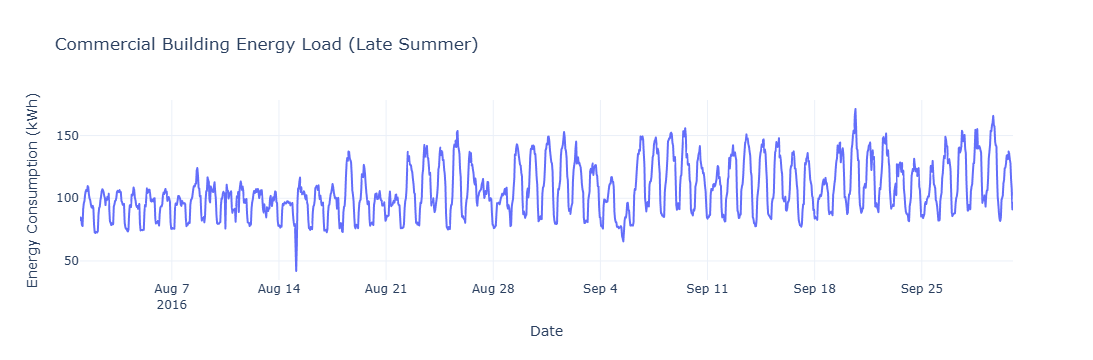

In [2]:
# Plot a 2-month slice to clearly see daily and weekly rhythms
df_slice = df.loc['2016-08-01':'2016-09-30']

fig = px.line(
    df_slice, 
    y='energy_kwh', 
    title='Commercial Building Energy Load (Late Summer)',
    labels={'datetime': 'Date', 'energy_kwh': 'Energy Consumption (kWh)'}
)
fig.update_layout(template='plotly_white')
fig.show()

## Uncovering Seasonality
Notice the clear drops on weekends. If a microgrid AI can accurately forecast these standard drops, it can schedule battery discharging optimally. Anomalies (spikes on weekends) usually indicate equipment failing to shut down.

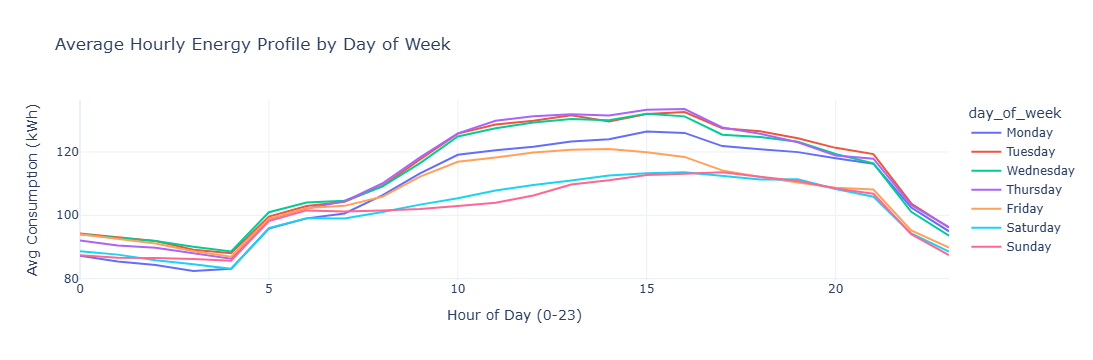

In [3]:
# Calculate average load by hour of the day and day of the week
df['hour'] = df.index.hour
df['day_of_week'] = df.index.day_name()

# Group and average
hourly_avg = df.groupby(['day_of_week', 'hour'])['energy_kwh'].mean().reset_index()

# Order the days correctly
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
fig = px.line(
    hourly_avg, 
    x='hour', 
    y='energy_kwh', 
    color='day_of_week',
    category_orders={"day_of_week": days_order},
    title='Average Hourly Energy Profile by Day of Week',
    labels={'hour': 'Hour of Day (0-23)', 'energy_kwh': 'Avg Consumption (kWh)'}
)
fig.update_layout(template='plotly_white')
fig.show()